In [14]:
import sys
import os
import psycopg2
from dotenv import load_dotenv
import QuantLib as ql


sys.path.append(os.path.abspath(".."))
from utils.black_scholes import get_implied_vol

load_dotenv()

url = os.getenv("DATABASE_URL")

In [15]:
conn = psycopg2.connect(url, sslmode="require")
cur = conn.cursor()

In [40]:
postfix_list = [
    "CD6E", #04-29
]
expiry_date = ql.Date(29, 4, 2026)
eval_date = ql.Date(16, 4, 2026)
option_type = "call"

ticker = "SR"
min_strike = 270
max_strike = 370
strike_step = 10

strike = min_strike
tickers = []
while strike < max_strike:
    for postfix in postfix_list:
        option_ticker = ticker + str(strike) + postfix
        tickers.append(option_ticker)
    strike += strike_step
print(tickers)

['SR270CD6E', 'SR280CD6E', 'SR290CD6E', 'SR300CD6E', 'SR310CD6E', 'SR320CD6E', 'SR330CD6E', 'SR340CD6E', 'SR350CD6E', 'SR360CD6E']


In [41]:
query = """
SELECT DISTINCT ON (ticker)
    ticker,
    bids,
    asks
FROM orderbooks
WHERE ticker = ANY(%s)
ORDER BY ticker, timestamp DESC;
"""

cur.execute(query, (tickers,))
rows = cur.fetchall()

In [42]:
rows

[('SR270CD6E',
  [{'price': 53.55, 'quantity': 800}],
  [{'price': 54.99, 'quantity': 800}]),
 ('SR280CD6E', [], [{'price': 45.05, 'quantity': 800}]),
 ('SR290CD6E',
  [{'price': 33.8, 'quantity': 800},
   {'price': 33.63, 'quantity': 800},
   {'price': 33.15, 'quantity': 800},
   {'price': 33.07, 'quantity': 800},
   {'price': 10.15, 'quantity': 10}],
  [{'price': 33.97, 'quantity': 800},
   {'price': 34.48, 'quantity': 800},
   {'price': 35.05, 'quantity': 800}]),
 ('SR300CD6E',
  [{'price': 23.74, 'quantity': 800},
   {'price': 23.4, 'quantity': 800},
   {'price': 20.21, 'quantity': 800},
   {'price': 0.02, 'quantity': 110}],
  [{'price': 24.06, 'quantity': 800},
   {'price': 24.47, 'quantity': 800},
   {'price': 24.63, 'quantity': 800},
   {'price': 24.88, 'quantity': 800}]),
 ('SR310CD6E',
  [{'price': 13.93, 'quantity': 800},
   {'price': 13.56, 'quantity': 800},
   {'price': 13.4, 'quantity': 800},
   {'price': 11.03, 'quantity': 800},
   {'price': 0.02, 'quantity': 110}],
  [{'

In [43]:
def compute_mid_price(bids, asks):
    best_bid = None
    best_ask = None
    
    if bids:
        best_bid = max(bids, key=lambda x: x["price"])["price"]
    if asks:
        best_ask = min(asks, key=lambda x: x["price"])["price"]

    if best_bid is not None and best_ask is not None:
        return (best_bid + best_ask) / 2
    return best_bid or best_ask

In [44]:
result = []

for ticker, bids, asks in rows:
    mid = compute_mid_price(bids, asks)

    result.append({
        "ticker": ticker,
        "mid": mid,
    })
result

[{'ticker': 'SR270CD6E', 'mid': 54.269999999999996},
 {'ticker': 'SR280CD6E', 'mid': 45.05},
 {'ticker': 'SR290CD6E', 'mid': 33.885},
 {'ticker': 'SR300CD6E', 'mid': 23.9},
 {'ticker': 'SR310CD6E', 'mid': 14.254999999999999},
 {'ticker': 'SR320CD6E', 'mid': 6.43},
 {'ticker': 'SR330CD6E', 'mid': 1.495},
 {'ticker': 'SR340CD6E', 'mid': 0.45},
 {'ticker': 'SR350CD6E', 'mid': 0.46},
 {'ticker': 'SR360CD6E', 'mid': 0.94}]

In [52]:
data = result
spot_price = 322
risk_free_rate = 0.15

result = []

for r in data:
    ticker = r["ticker"]
    mid = r["mid"]
    strike = int(r["ticker"][2:5])


    if strike is None:
        continue

    try:
        iv = get_implied_vol(
            market_price=mid,
            spot_price=spot_price,
            strike_price=strike,
            risk_free_rate=risk_free_rate,
            expiry_date=expiry_date,
            eval_date=eval_date,
            option_type=option_type
            )
    except Exception as e:
        iv = None
        print(e)
        

    result.append({
        "strike": strike,
        "mid": mid,
        "iv": iv,
        "ticker": ticker
    })
result

[{'strike': 270,
  'mid': 54.269999999999996,
  'iv': 0.6101008698843925,
  'ticker': 'SR270CD6E'},
 {'strike': 280, 'mid': 45.05, 'iv': 0.595341491990762, 'ticker': 'SR280CD6E'},
 {'strike': 290,
  'mid': 33.885,
  'iv': 0.3390051321135014,
  'ticker': 'SR290CD6E'},
 {'strike': 300,
  'mid': 23.9,
  'iv': 0.24550470684964423,
  'ticker': 'SR300CD6E'},
 {'strike': 310,
  'mid': 14.254999999999999,
  'iv': 0.18823699617361644,
  'ticker': 'SR310CD6E'},
 {'strike': 320,
  'mid': 6.43,
  'iv': 0.17954590051655386,
  'ticker': 'SR320CD6E'},
 {'strike': 330,
  'mid': 1.495,
  'iv': 0.15666450341798657,
  'ticker': 'SR330CD6E'},
 {'strike': 340,
  'mid': 0.45,
  'iv': 0.18841051372221143,
  'ticker': 'SR340CD6E'},
 {'strike': 350,
  'mid': 0.46,
  'iv': 0.26935327957924127,
  'ticker': 'SR350CD6E'},
 {'strike': 360,
  'mid': 0.94,
  'iv': 0.40155771398694223,
  'ticker': 'SR360CD6E'}]

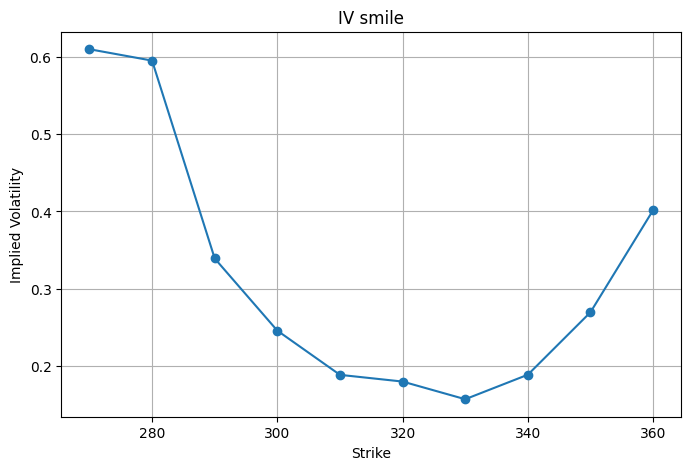

In [53]:
import matplotlib.pyplot as plt

strikes = [x["strike"] for x in data]
ivs = [x["iv"] for x in data]

plt.figure(figsize=(8,5))
plt.plot(strikes, ivs, marker="o")

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("IV smile")
plt.grid(True)

plt.show()